In [1]:
import os
import sys
sys.path.append('../') # Add parent directory to path (from env to parent)

import numpy as np 
from matplotlib import pyplot as plt

import scipy.stats as kde
import pandas as pd
import processing_functions as pf
import post_processing_functions as ppf

import importlib
importlib.reload(ppf)

<module 'post_processing_functions' from 'c:\\Users\\lsito\\Desktop\\XBox_Processing\\scratch\\post_processing_functions.py'>

# User input
Here the user input is needed. 
* 'Xbox" is according to the chosen X-box
* 'structure_name' is according to the folder name onthe DFS server
* 'file_name' is the appendix of the file the data will be saved to. This will be a costruction of the structure name and the file name
* 'startdate' and 'enddate are used to limit the extracted data. Only data after or at the startstate and before the enddate will be extracted.
* if the BD positions should be plotted, 'plotting' needs to be True
* t_fill is the filling time of the structure used to calculate the BD time. With changing the strucutre, this can be adjusted
* Pref and Gref is according to the structure infomration
* structure_stand has to be chosen for XBo2 2 to only plot information for one stand!

From the 'structure_name' the test stand (A, B or both) is known. If a new strucutre is used later, this needs to be adjusted.

The output data will be saved locally in the folder 'processed_data' with the subfolder according to the structure name. If a different setup is wanted, 'save_directory' needs to be adjusted




In [3]:
structure_name='Xbox2_TD31N3N4'
sel_struct="A"

structure_name='Xbox3_TD26CIEMAT_L1'

folder_name='_pandas_new_test'
startdate=np.datetime64('2026-01-06T00:00:00.000000')
enddate=np.datetime64('2026-01-08T00:00:00.000000')

plotting = False

load_directory=(r"../data/"+structure_name+"/"+structure_name+folder_name+".h5")

if structure_name=='Xbox2_TD31N3N4':
    if sel_struct=="A":
        structure_stand=1
    elif sel_struct=="B":
        structure_stand=2
    else:
        print("Error, not a valid Structure")
    Xbox=2 
    t_fill=60e-9
    P_ref = 36.1  # [MW]
    G_ref = 72  # MV/m 
elif structure_name=='Xbox2_TD31N3N4_B':
    #choose one!!
    structure_stand=2
    Xbox=2 
    t_fill=60e-9
    P_ref = 36.1  # [MW]
    G_ref = 72  # MV/m 
elif structure_name=='Xbox3_TD31N1_L1':
    structure_stand=1
    Xbox=3
    t_fill=60e-9
    P_ref = 36.1  # [MW]
    G_ref = 72  # MV/m
elif structure_name=='Xbox3_TD31N2_L2':
    structure_stand=2
    Xbox=3
    t_fill=60e-9
    P_ref = 36.1  # [MW]
    G_ref = 72  # MV/m

elif structure_name=='Xbox3_T24N4_L2':
    structure_stand=2
    Xbox=3
    t_fill=57.25e-9
    P_ref = 38.5  # [MW]
    G_ref = 100  # MV/m

elif structure_name=='Xbox3_TD26CIEMAT_L1':
    structure_stand=1
    Xbox=3
    t_fill=57.25e-9
    P_ref = 42.3  # [MW]
    G_ref = 100  # MV/m

    

In [4]:
#open all data in one folder
all_data=pf.load_event_data(load_directory)

#adjust Peak power and Pulse length 
adjusted_data=ppf.adjust_variables(all_data,Xbox,structure_stand)
print(adjusted_data.keys())

FileNotFoundError: ``C:\Users\lsito\Desktop\XBox_Processing\data\Xbox3_TD26CIEMAT_L1`` does not exist

In [6]:
print(adjusted_data['timestamp'])

0      2025-10-02 09:14:42.218886
1      2025-10-02 09:15:42.218907
2      2025-10-02 09:16:42.218901
3      2025-10-02 09:17:42.218897
4      2025-10-02 09:18:42.218936
                  ...            
7117   2025-10-15 14:44:31.958122
7118   2025-10-15 14:45:11.973117
7119   2025-10-15 14:45:51.968173
7120   2025-10-15 14:46:31.976076
7121   2025-10-15 14:46:38.592186
Name: timestamp, Length: 7122, dtype: datetime64[ns]


(0.0, 3.0)

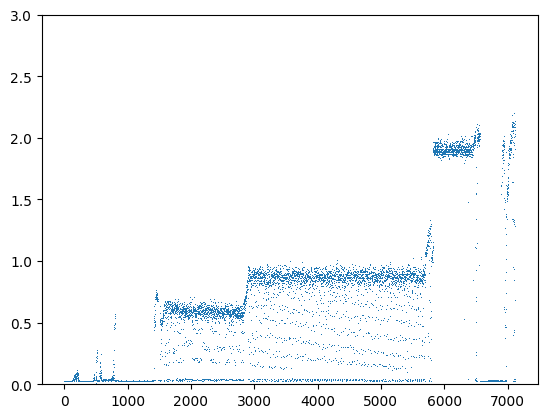

In [7]:
plt.plot(adjusted_data["PSIA_peak"],",")
plt.ylim([0,3])

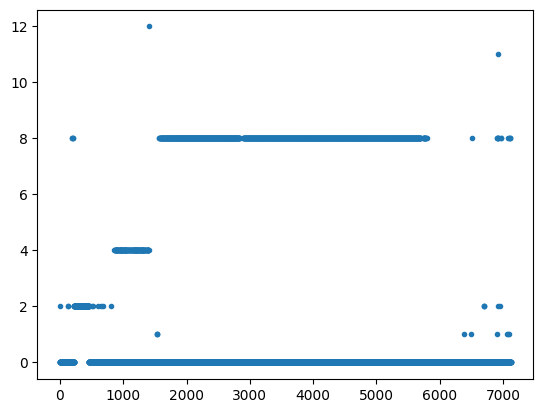

In [8]:
plt.plot(adjusted_data["BD_loc"],'.')

a
(6854, 46)


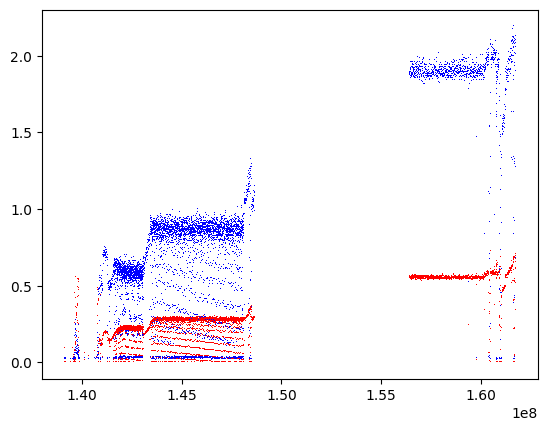

In [9]:

#PSI peak at least 5e6 (already downconverted)
#filter out wrong PSI detections
structure_data=ppf.filter_PSI(adjusted_data,structure_stand,min_value=10e-6,max_value=100)

#filter data as wanted
structure_data=ppf.filter_PKI(structure_data,Xbox,structure_stand,min_value=0.1e-6,max_value=100)
structure_data.reset_index(drop=True, inplace=True)
print(structure_data.shape)


plt.plot(structure_data["pulse_count"],structure_data["PKIA_peak"]/1e6,'r,')
plt.plot(structure_data["pulse_count"],structure_data["PSIA_peak"],'b,')

In [10]:
print(np.max(structure_data['gradient_A']))
print(np.max(structure_data['PSIA_peak']))

KeyError: 'gradient_A'

In [11]:
#print(structure_data.keys())
print(all_data.keys())
print

Index(['pulse_count', 'log_type', 'timestamp', 'PKIA_total_power',
       'PKIA_length', 'PKIA_peak', 'PKIA_mean', 'PKIA_start',
       'PKIB_total_power', 'PKIB_length', 'PKIB_peak', 'PKIB_mean',
       'PKIB_start', 'PKRA_total_power', 'PKRA_length', 'PKRA_peak',
       'PKRA_mean', 'PKRA_start', 'PKRB_total_power', 'PKRB_length',
       'PKRB_peak', 'PKRB_mean', 'PKRB_start', 'PLRA_total_power',
       'PLRB_total_power', 'PSIA_total_power', 'PSIA_peak', 'PSIA_peak_length',
       'PSIA_mean_flat', 'PSIA_start', 'PSIA_t', 'PSRA_total_power',
       'PSRA_total_power_including_offset', 'PSRA_t', 'PEIA_total_power',
       'PEIA_peak', 'PEIA_peak_length', 'PEIA_mean_flat', 'PEIA_start',
       'PEIA_t', 'DC_up_total_A', 'DC_up_peak_A', 'DC_down_total_A',
       'DC_down_peak_A', 'BD_struct', 'BD_loc'],
      dtype='object')


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

2025-10-15T14:46:38.592186000
0       139124160
1       139124160
2       139124160
3       139124160
4       139124160
          ...    
6849    161689133
6850    161693505
6851    161699499
6852    161705508
6853    161706497
Name: pulse_count, Length: 6854, dtype: int64


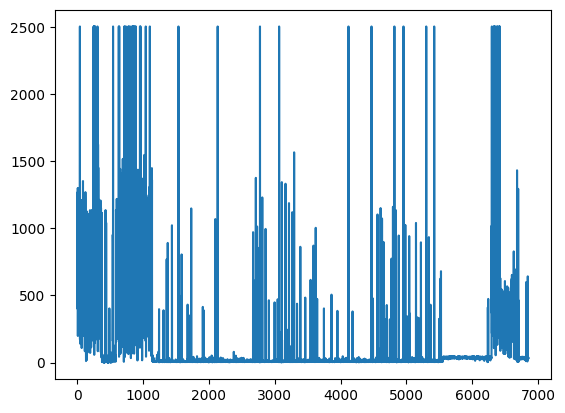

In [12]:
plt.plot(structure_data["PSIA_peak_length"])

print(structure_data["timestamp"].to_numpy()[-1])
print(structure_data["pulse_count"])

In [13]:
#calculate BDR and cummul. BD and append
structure_data=pf.calculate_BDR(structure_data,Xbox,structure_stand)
structure_data=pf.calculate_BD_pos(structure_data,Xbox,structure_stand, t_fill)

/home/lsito/XBox_Processing/notebooks/../src/processing_functions.py:710: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  input_data.loc[i, "BDR_DUT_A"] = ((input_data.loc[i, "cum_BD_DUT_withDC_A"] + input_data.loc[i, "cum_BD_DUT_withoutDC_A"]) - (input_data.loc[last_pulse_j, "cum_BD_DUT_withDC_A"] + input_data.loc[last_pulse_j, "cum_BD_DUT_withoutDC_A"])) / amount_BDR_sum
/home/lsito/XBox_Processing/notebooks/../src/processing_functions.py:711: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  input_data.loc[i, "BDR_Load_A"] = (input_data.loc[i, "cum_BD_Load_A"] - input_data.loc[last_pulse_j, "cum_BD_Load_A"]) / amount_BDR_sum
/home/lsito/

In [14]:
#filter out BDs
# with DC flow
BD_data_with_DC=structure_data[(structure_data["BD_loc"]==2)]
# without BDC flow
BD_data_without_DC=structure_data[(structure_data["BD_loc"]==4) ]
#all BD data
BD_data=pd.concat([BD_data_with_DC,BD_data_without_DC])


In [15]:
rate_BD_w_BDC=len(BD_data_with_DC)/len(BD_data)
rate_BD_wo_BDC=len(BD_data_without_DC)/len(BD_data)
print(rate_BD_w_BDC)
print(rate_BD_wo_BDC)

0.0
1.0


       pulse_count  log_type                  timestamp  PKIA_total_power  \
561            140         2 2025-06-13 08:47:22.689506          0.118273   
661          11224         2 2025-06-13 09:46:24.739464          0.264019   
673          15013         2 2025-06-13 09:53:01.329535          0.269345   
1726        153210         2 2025-06-13 13:42:29.152453          0.331722   
2756        680133         2 2025-06-20 12:34:48.799775          0.140848   
...            ...       ...                        ...               ...   
56928    140905171         2 2025-10-13 13:26:40.382161         -0.001095   
56930    140905171         2 2025-10-13 13:26:40.452150         -0.001093   
56932    140905171         2 2025-10-13 13:26:40.803114         -0.001095   
56933    140905171         2 2025-10-13 13:26:40.849199         -0.001097   
56947    140905172         2 2025-10-13 13:33:32.582157          0.334999   

        PKIA_length    PKIA_peak      PKIA_mean    PKIA_start  \
561    8.6

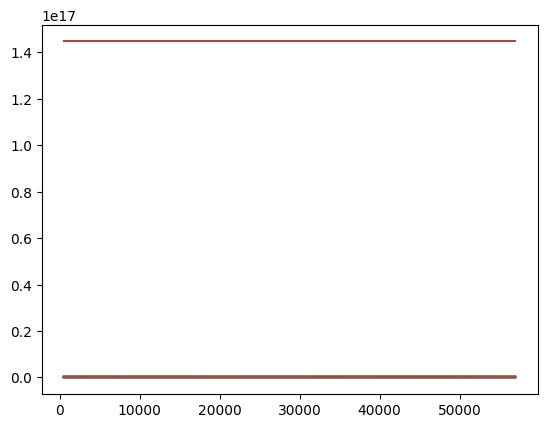

In [25]:
plt.plot(BD_data)

print(BD_data)

In [ ]:

#calculation for plot of BD pos

kernel_factor=20.
[xi,yi,positions]=ppf.gaussian_kde_position(structure_data)
zi=ppf.gaussian_kde_calculation(kernel_factor,BD_data,xi,positions)

#filter out last BD data (to do plot with zoom)
BD_data_last=BD_data[(BD_data["timestamp"]>=startdate)&(BD_data["timestamp"]<enddate)]
last_data = structure_data.query("@startdate < timestamp < @enddate")


[xi_last,yi_last,positions_last]=ppf.gaussian_kde_position(last_data)
zi_last=ppf.gaussian_kde_calculation(kernel_factor,BD_data_last,xi_last,positions_last)


ValueError: `dataset` input should have multiple elements.

Text(0.5, 0, '# pulses [$\\times 10^6$]')

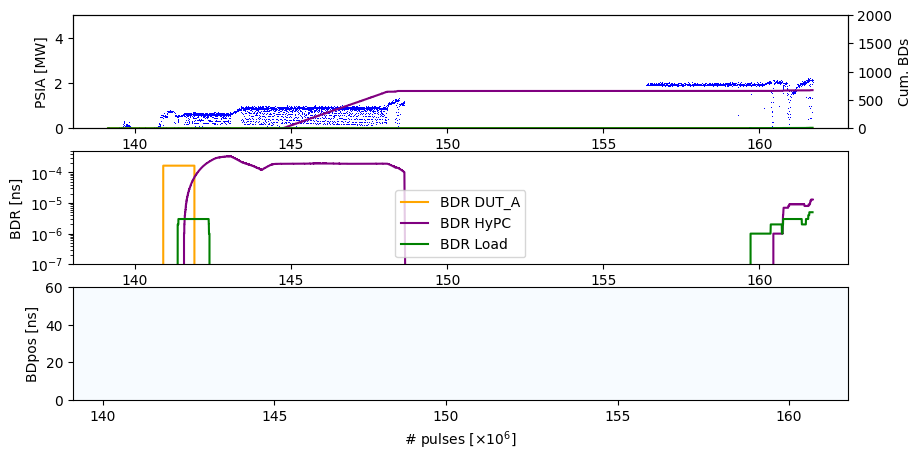

In [ ]:
fig,ax=plt.subplots(3,1,figsize=(10,5))
from matplotlib import colors as mcolors

normaldata=structure_data.query("log_type!=2")
normaldata=normaldata.query("PKIA_length>10e-9")

ax[0].plot(normaldata["pulse_count"]/1e6,normaldata["PSIA_peak"],',b')
ax[0].plot(normaldata["pulse_count"]/1e6,normaldata["PKIA_mean"]*1e6,',r')
ax2=ax[0].twinx()
ax2.plot(normaldata["pulse_count"]/1e6,normaldata["cum_BD_DUT_withDC_A"],'orange')
ax2.plot(normaldata["pulse_count"]/1e6,normaldata["cum_BD_HyPC_A"]-700,'purple') #because I messed up
ax2.plot(normaldata["pulse_count"]/1e6,normaldata["cum_BD_Load_A"],'g')
#ax3=ax[0].twinx()
ax[0].set_ylabel("PSIA [MW]")
#ax3.set_ylabel("PKI length [ns]")
ax2.set_ylabel("Cum. BDs")
ax[0].set_ylim([0,5])
ax2.set_ylim([0,2000])

ax[1].plot(normaldata["pulse_count"]/1e6,normaldata["BDR_DUT_A"],color='orange', marker=',')
ax[1].plot(normaldata["pulse_count"]/1e6,normaldata["BDR_HyPC_A"],color='purple', marker=',')
ax[1].plot(normaldata["pulse_count"]/1e6,normaldata["BDR_Load_A"],'g')
ax[1].set_yscale('log')
ax[1].set_ylim([1e-7,5e-4])
ax[1].set_ylabel("BDR [ns]")
#ax[1].set_xlim([0,35])
ax[1].legend(['BDR DUT_A','BDR HyPC','BDR Load',])

ax[2].pcolormesh(xi/1e6,yi,zi,cmap="Blues",norm=mcolors.PowerNorm(0.5),alpha=1,shading='auto')
ax[2].contour(xi/1e6,yi,zi,cmap='gray',alpha=0.2,linewidths=0.5)
ax[2].set_ylabel("BDpos [ns]")
ax[2].set_xlabel(r"# pulses [$\times 10^6$]")

Empty DataFrame
Columns: [pulse_count, log_type, timestamp, PKIA_total_power, PKIA_length, PKIA_peak, PKIA_mean, PKIA_start, PKIB_total_power, PKIB_length, PKIB_peak, PKIB_mean, PKIB_start, PKRA_total_power, PKRA_length, PKRA_peak, PKRA_mean, PKRA_start, PKRB_total_power, PKRB_length, PKRB_peak, PKRB_mean, PKRB_start, PLRA_total_power, PLRB_total_power, PSIA_total_power, PSIA_peak, PSIA_peak_length, PSIA_mean_flat, PSIA_start, PSIA_t, PSRA_total_power, PSRA_total_power_including_offset, PSRA_t, PEIA_total_power, PEIA_peak, PEIA_peak_length, PEIA_mean_flat, PEIA_start, PEIA_t, DC_up_total_A, DC_up_peak_A, DC_down_total_A, DC_down_peak_A, BD_struct, BD_loc, lost_power_A, gradient_A, cum_BD_Load_A, cum_BD_DUT_withDC_A, cum_BD_DUT_withoutDC_A, cum_BD_HyPC_A, BDR_DUT_A, BDR_Load_A, BDR_HyPC_A, BD_time]
Index: []

[0 rows x 56 columns]


In [39]:
save_directory=r"/"+structure_name+"_Structure"+str(structure_stand)+"_PeakPlot_overall_pandas"     
ppf.plot_3_in_1_peak_plot(structure_data,last_data,xi,yi,zi,xi_last,yi_last,zi_last,structure_stand,Xbox,save_directory)

NameError: name 'zi_last' is not defined